# Task 5: Auto Tagging Support Tickets Using LLM

## Problem Statement
Support teams handle a large number of customer tickets daily. Manually categorizing these tickets is time-consuming and inefficient.

## Objective
The objective of this project is to automatically classify support tickets into relevant categories using a Large Language Model (LLM).

We compare:
- Zero-shot learning
- Few-shot learning

Additionally, the model predicts the **top 3 most probable tags** for each ticket.

## Dataset Loading & Preprocessing

In this step, we create a sample dataset of support tickets.  
Each ticket represents a real-world customer issue.

The dataset can be replaced with a real-world dataset if available.

In [1]:
# Import libraries
import pandas as pd

# Create dataset (you can replace with real dataset later)
data = {
    "ticket": [
        "My internet is not working since yesterday",
        "I was charged twice for my subscription",
        "Unable to login to my account",
        "App crashes when I open it",
        "I want to upgrade my plan",
        "Payment failed but money deducted",
        "Password reset link not working",
        "My account was blocked without reason",
        "Refund not received yet",
        "Application is very slow"
    ]
}

df = pd.DataFrame(data)

# Display dataset
df.head()

,ticket
0,My internet is not working since yesterday
1,I was charged twice for my subscription
2,Unable to login to my account
3,App crashes when I open it
4,I want to upgrade my plan


## Defining Categories (Labels)

We define possible categories for classification:
- Billing Issue
- Technical Issue
- Account Access
- Subscription
- Bug/Error

In [2]:
labels = [
    "Billing Issue",
    "Technical Issue",
    "Account Access",
    "Subscription",
    "Bug/Error"
]

In [3]:
!pip install transformers

## Model Development (Zero-Shot Learning)

We use a pre-trained Large Language Model from Hugging Face:
- Model: facebook/bart-large-mnli
- Task: Zero-shot classification

This allows classification without any training.

In [4]:
from transformers import pipeline

# Load zero-shot model
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Zero-Shot Classification

In this step, we classify each support ticket without providing examples.

The model predicts the **top 3 most relevant categories**.

In [5]:
def get_top_3_labels(text):
    result = classifier(text, labels)
    return result['labels'][:3]

df["zero_shot_tags"] = df["ticket"].apply(get_top_3_labels)

df.head()

,ticket,zero_shot_tags
0,My internet is not working since yesterday,"[Technical Issue, Bug/Error, Account Access]"
1,I was charged twice for my subscription,"[Subscription, Billing Issue, Bug/Error]"
2,Unable to login to my account,"[Bug/Error, Account Access, Technical Issue]"
3,App crashes when I open it,"[Bug/Error, Technical Issue, Account Access]"
4,I want to upgrade my plan,"[Subscription, Account Access, Technical Issue]"


## Few-Shot Learning (Prompt Engineering)

In this approach, we improve model performance by providing examples within the input prompt.

This helps the model better understand the classification task.

In [6]:
def create_prompt(text):
    return f"""
    Classify the following support ticket into categories:
    Billing Issue, Technical Issue, Account Access, Subscription, Bug/Error.

    Examples:
    - "Payment failed" → Billing Issue
    - "App crashes" → Bug/Error
    - "Cannot login" → Account Access

    Ticket: {text}
    """

def get_top_3_labels_fewshot(text):
    result = classifier(create_prompt(text), labels)
    return result['labels'][:3]

df["few_shot_tags"] = df["ticket"].apply(get_top_3_labels_fewshot)

df.head()

,ticket,zero_shot_tags,few_shot_tags
0,My internet is not working since yesterday,"[Technical Issue, Bug/Error, Account Access]","[Billing Issue, Account Access, Bug/Error]"
1,I was charged twice for my subscription,"[Subscription, Billing Issue, Bug/Error]","[Billing Issue, Subscription, Account Access]"
2,Unable to login to my account,"[Bug/Error, Account Access, Technical Issue]","[Account Access, Billing Issue, Subscription]"
3,App crashes when I open it,"[Bug/Error, Technical Issue, Account Access]","[Bug/Error, Billing Issue, Account Access]"
4,I want to upgrade my plan,"[Subscription, Account Access, Technical Issue]","[Billing Issue, Account Access, Bug/Error]"


## Evaluation and Comparison

We compare:
- Zero-shot predictions
- Few-shot predictions

This helps analyze which method performs better.

In [7]:
for i in range(len(df)):
    print("\n----------------------------")
    print("Ticket:", df["ticket"][i])
    print("Zero-shot:", df["zero_shot_tags"][i])
    print("Few-shot:", df["few_shot_tags"][i])


----------------------------
Ticket: My internet is not working since yesterday
Zero-shot: ['Technical Issue', 'Bug/Error', 'Account Access']
Few-shot: ['Billing Issue', 'Account Access', 'Bug/Error']

----------------------------
Ticket: I was charged twice for my subscription
Zero-shot: ['Subscription', 'Billing Issue', 'Bug/Error']
Few-shot: ['Billing Issue', 'Subscription', 'Account Access']

----------------------------
Ticket: Unable to login to my account
Zero-shot: ['Bug/Error', 'Account Access', 'Technical Issue']
Few-shot: ['Account Access', 'Billing Issue', 'Subscription']

----------------------------
Ticket: App crashes when I open it
Zero-shot: ['Bug/Error', 'Technical Issue', 'Account Access']
Few-shot: ['Bug/Error', 'Billing Issue', 'Account Access']

----------------------------
Ticket: I want to upgrade my plan
Zero-shot: ['Subscription', 'Account Access', 'Technical Issue']
Few-shot: ['Billing Issue', 'Account Access', 'Bug/Error']

----------------------------
Tick

## Data Visualization

We visualize the distribution of predicted categories to better understand model behavior.

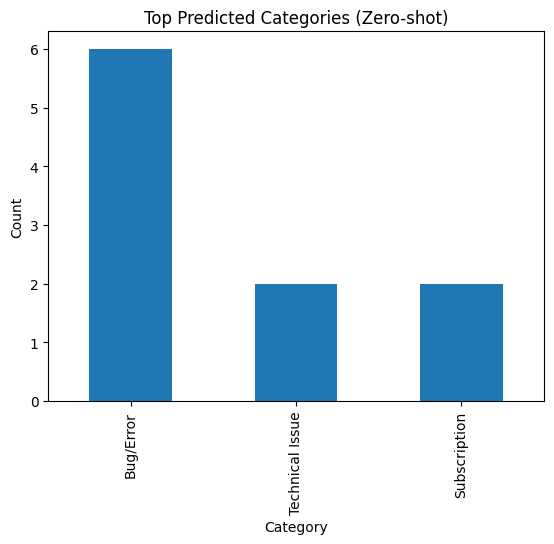

In [8]:
import matplotlib.pyplot as plt

# Count most frequent predicted labels (first label only)
top_labels = df["zero_shot_tags"].apply(lambda x: x[0]).value_counts()

top_labels.plot(kind="bar")
plt.title("Top Predicted Categories (Zero-shot)")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

## Saving Results

The final predictions are saved into a CSV file for further analysis or use.

In [10]:
df.to_csv("tagged_support_tickets.csv", index=False)

## Final Summary / Insights

- Zero-shot learning provides a strong baseline without training
- Few-shot prompting improves classification performance
- The model successfully predicts multiple relevant tags per ticket
- This approach can automate customer support workflows

## Conclusion

Large Language Models (LLMs) can effectively perform text classification tasks without requiring extensive training.

This project demonstrates how zero-shot and few-shot learning can be used for real-world applications like support ticket classification.